## Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df=pd.read_csv(r"data.csv",on_bad_lines='skip')
df.head()
print("Shape:",df.shape)

Shape: (669640, 2)


## Check Class Distribution

strength
1    496801
0     89702
2     83137
Name: count, dtype: int64


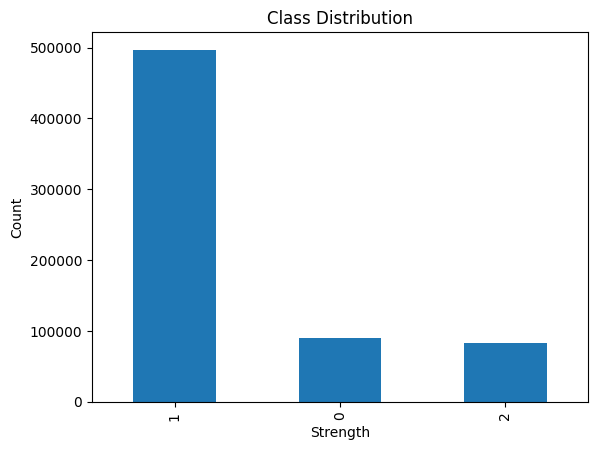

In [3]:
print(df['strength'].value_counts())

df['strength'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
plt.show()

## Handle Missing Values

In [4]:
df.dropna(inplace=True)

## Features & Labels

In [5]:
X = df['password']
y = df['strength']

## TF-IDF Vectorization 

In [6]:
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(1, 3),
    max_features=50000
)

X_vectorized = vectorizer.fit_transform(X)

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

## Train Model
### Handling imbalance here

In [8]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Predictions

In [9]:
y_pred = model.predict(X_test)

## Accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9145809688788006


## Detailed Evaluation

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78     17908
           1       0.99      0.90      0.94     99519
           2       0.94      0.96      0.95     16501

    accuracy                           0.91    133928
   macro avg       0.86      0.94      0.89    133928
weighted avg       0.94      0.91      0.92    133928



## Confusion Matrix

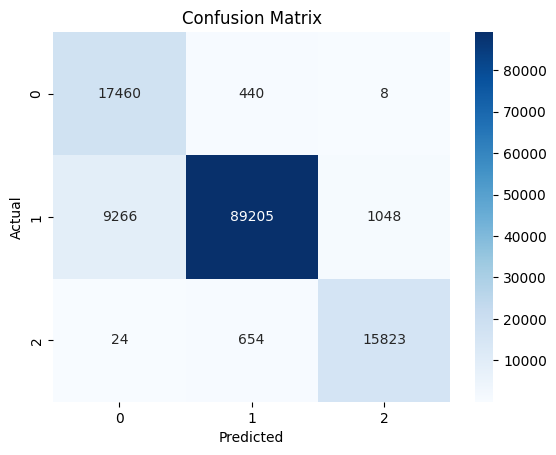

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Prediction Function

In [13]:
def check_password(password):
    vec = vectorizer.transform([password])
    pred = model.predict(vec)[0]

    if pred == 0:
        return "Weak ❌"
    elif pred == 1:
        return "Medium ⚠️"
    else:
        return "Strong ✅"

In [14]:
check_password("P@ssw0rd123")

'Strong ✅'

## Interactive Testing

In [ ]:
while True:
    pwd = input("Enter password (or exit): ")
    if pwd.lower() == "exit":
        break
    print(check_password(pwd))

Enter password (or exit):  pass


Weak ❌


Enter password (or exit):  khani


Weak ❌


Enter password (or exit):  pass@345


Medium ⚠️


Enter password (or exit):  P@ss123


Weak ❌


Enter password (or exit):  P@@ss#$@#


Strong ✅


Enter password (or exit):  pass@12341234


Strong ✅


Enter password (or exit):  khani


Weak ❌


Enter password (or exit):  wjkdfhijwbdc


Medium ⚠️


Enter password (or exit):  khanishka


Medium ⚠️


Enter password (or exit):  rama


Weak ❌


Enter password (or exit):  raavana


Weak ❌
